#**Objetivos**

* Hacer un modelo que prediga la posible salida de clientes.
* Obtener un Pipeline de procesamiento de datos.
* Obtener el modelo más adecuado al problema.

##**Pasos**
* Revisar la calidad de la data (Tipos de datos, valores nulos, duplicados y valores negativos que no correspondan)
* Hacer un análisis exploratorio univariado y bivariado, además de incluir métodos de aprendizaje no supervisado como PCA y TNSE.
* Construir pipelines de Procesamiento basado en el análisis exploratorio de datos.
* Probar distintos modelos de clasificación lineales y no lineales.
* Realizar una búsqueda de hiperparámetros inicial para detectar el modelo más adecuado al problema.






#**Librerías**

##**Instalar librería para procesamiento de datos**

In [45]:
!pip install feature_engine

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from feature_engine.encoding import OneHotEncoder, OrdinalEncoder
from feature_engine.wrappers import SklearnTransformerWrapper
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from matplotlib.cm import ScalarMappable
from matplotlib.colors import  Normalize
from scipy.stats.contingency import association
from sklearn.base import BaseEstimator, clone, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, precision_recall_curve, PrecisionRecallDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#**Cargar el Dataset**

In [47]:
df = pd.read_csv('Telco-Customer-Churn.csv')

#**Exploración inicial del Dataset**

In [48]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##**Valores duplicados**

In [49]:
duplicados = df.duplicated()
duplicados[duplicados > 0]

,0


##**Eliminar la Columna CustomerID**

In [50]:
df = df.drop(columns='customerID')

##**Tamaño del Dataset**

In [51]:
df.shape

(7043, 20)

##**Valores nulos**

In [52]:
nulos = df.isnull().sum()
nulos[nulos>0]

,0


#**Tipos de datos**

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


##**Cambiar el tipo de dato de la columna TotalCharges**
Esto genera un error, por lo que luego se procederá averiguar por qué ocurre este error.

In [54]:
# df['TotalCharges'] = df['TotalCharges'].astype('float64')

##**Revisión de la columna TotalCharges**

In [55]:
regex_numeros = r'^\d+(?:\.\d+)?$'

solo_numeros = df['TotalCharges'].str.contains(regex_numeros, na = False).sum()
print(f'Total de filas del dataset: {df.shape[0]} \n Total de valores numéricos en columna Total Charges {solo_numeros}')

Total de filas del dataset: 7043 
 Total de valores numéricos en columna Total Charges 7032


##**Revisión de filas que no contienen valores numéricos**
Las filas que no contienen números en TotalCharges, no tienen ningún valor numérico, probablemente es un '', considerando las columnas tenure y Contract, probablemente son clientes que recién firmaron un contrato, por lo que lo más correcto sería reemplazar esos valores por 0

In [56]:
mascara_filas_sin_num = df['TotalCharges'].str.contains(regex_numeros, na = False)
filas_sin_numeros = df[~mascara_filas_sin_num]
filas_sin_numeros[['tenure','Contract','MonthlyCharges','TotalCharges']]

,tenure,Contract,MonthlyCharges,TotalCharges
488,0,Two year,52.55,
753,0,Two year,20.25,
936,0,Two year,80.85,
1082,0,Two year,25.75,
1340,0,Two year,56.05,
3331,0,Two year,19.85,
3826,0,Two year,25.35,
4380,0,Two year,20.00,
5218,0,One year,19.70,
6670,0,Two year,73.35,


##**Reemplazar valores faltantes por 0**

In [57]:
df['TotalCharges'] = df['TotalCharges'].str.replace(r'^\s*$', '0', regex=True)

df['TotalCharges'] = df['TotalCharges'].astype('float64')

##**Resumen estadístico de las variables numéricas**
* SeniorCitizen es una variable discreta ya que solo toma valores de números entre 0 y 1

In [58]:
df.select_dtypes(include=['number']).describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


#**Conclusiones de la exploración inicial**
* CustomerID no se utilizará para el modelo ya que es una variable que solo sirve para identificar al cliente.
* No hay valores duplicados.
* Tenure y SeniorCitizen son variables discretas.
* TotalCharges es un object o String en el Dataset y debería ser un Float.
* Habían valores nulos, pero no podían identificarse inicialmente ya que estaban como un string ' '.
* No hay presencia de valores negativos donde no corresponden.

#**Análisis exploratorio de Datos**

#**Análisis univariado**


##**Exploración de las variables cuantitativas**
Aquí analizaremos 2 gráficos de **distribución**:
* **Boxplot** para encontrar valores **atítpicos**, además de ver el rango de valores entre los que se encuentra la variable.
* **Histograma** para ver la forma que tiene la distribución.

In [59]:
df_cuantitativas = df.select_dtypes('number').drop(columns = 'SeniorCitizen').columns
colores_num = ['#4682B4', '#5F9EA0', '#CD853F']

##**Revisar Outliers en cada variable cuantitativa**
* No se observan Outliers

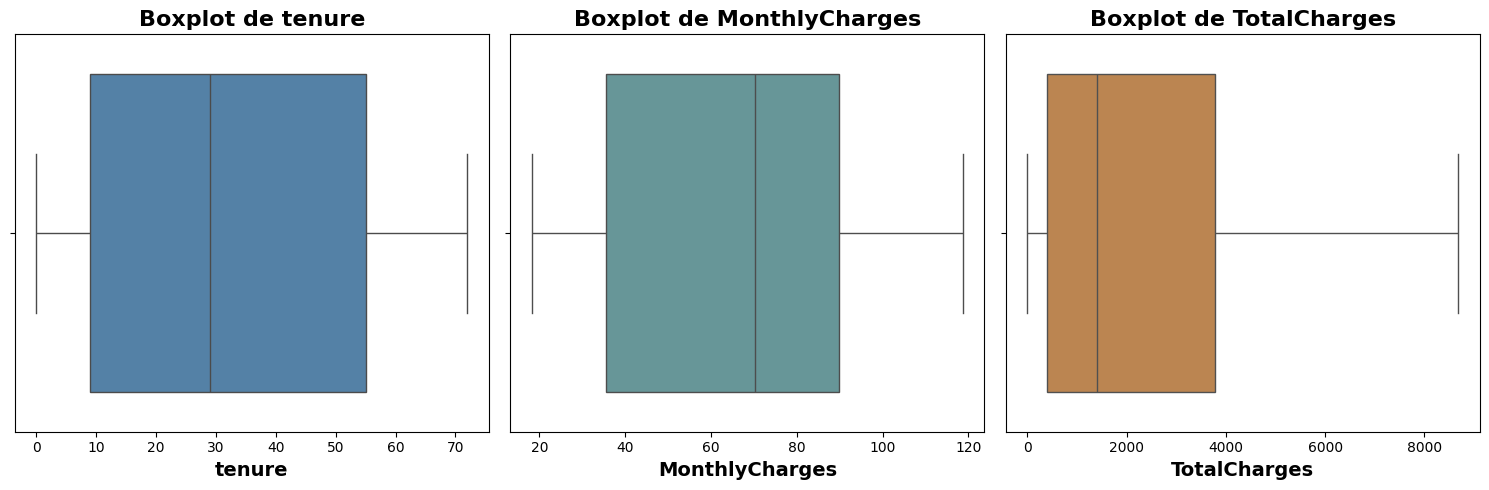

In [60]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

for j, col in enumerate(df_cuantitativas):
  ax[j] = sns.boxplot(df, x=col, ax=ax[j], color = colores_num[j])
  ax[j].set_title(f'Boxplot de {col}', fontsize = 16, fontweight = 'bold')
  ax[j].set_xlabel(f'{col}', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

##**Distribución de variables cuantitativas**
* La mayor cantidad de clientes llevan poco tiempo con el servicio, por eso se ve que en el gráfico de TotalCharges está muy cercano a 0.
* La variable TotalCharges podría hacerse una transformación con logaritmo +1, ya que se ve que tiene una cola a la derecha y para modelos lineales podría obtenerse mejores resultados.

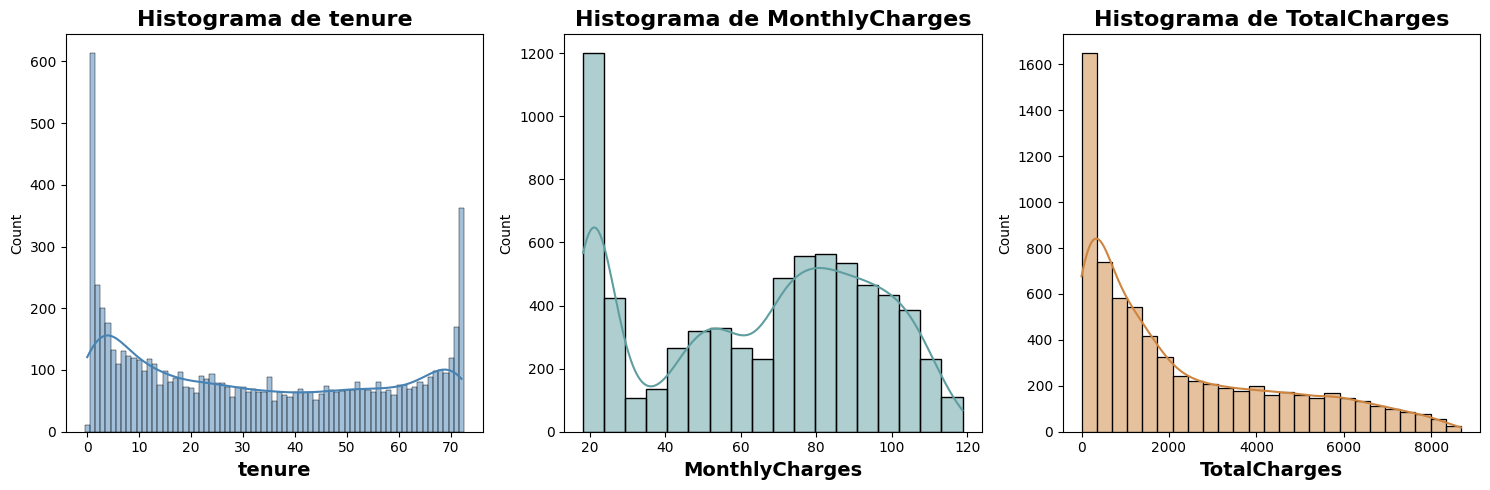

In [61]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5))

for j, col in enumerate(df_cuantitativas):
  if col == 'tenure':
    ax[j] = sns.histplot(df, x= col, kde = True, color= colores_num[j], ax = ax[j], discrete = True)
  else:
    ax[j] = sns.histplot(df, x= col, kde = True, color= colores_num[j], ax = ax[j])
  ax[j].set_xlabel(f'{col}',fontsize = 14, fontweight = 'bold')
  ax[j].set_title(f'Histograma de {col}', fontsize = 16, fontweight = 'bold')

plt.tight_layout()
plt.show()

##**Análisis SeniorCitizen (Variable Discreta)**
* Hay una gran diferencia entre las personas que no tienen ciudadanía, por lo que si podría ser una buena variable predictora.

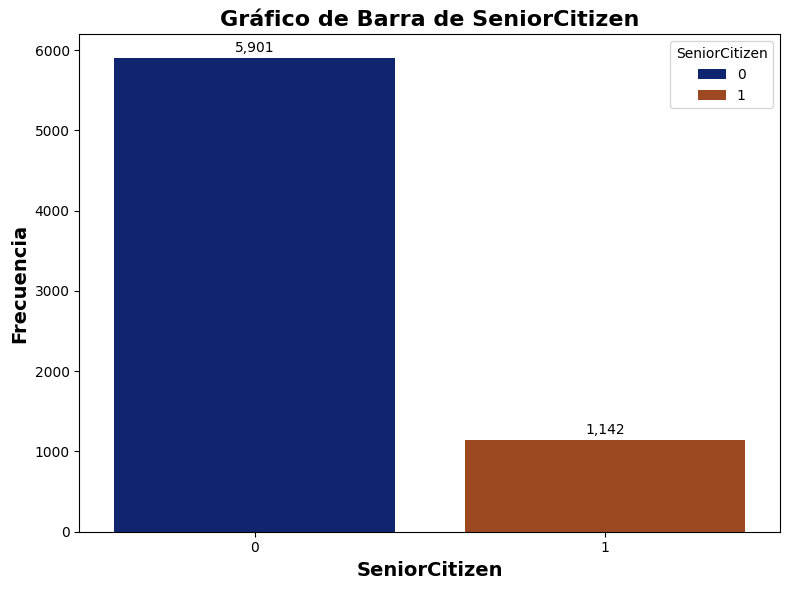

In [62]:
fig, ax = plt.subplots(figsize = (8,6))

ax = sns.countplot(df, x='SeniorCitizen', hue='SeniorCitizen', palette='dark')
ax.set_xlabel('SeniorCitizen', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Frecuencia', fontsize = 14, fontweight = 'bold')
ax.set_title('Gráfico de Barra de SeniorCitizen', fontsize = 16, fontweight = 'bold')
for container in ax.containers:
  ax.bar_label(container,padding = 2, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

##**Análisis Univariado de variables categóricas**

In [63]:
lista_categoricas = df.select_dtypes('object').drop(columns = 'Churn').columns
lista_categoricas

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

#**Gráfico que permita identificar Rare Labels o variables con mucha cardinalidad**
* No se aprecia ninguna variable con alta cardinalidad ya que todas tienen pocas categorías y tampoco se observa ninguna con rare Labels, si bien en algunas la proporción es menor, la cantidad de observaciones es suficiente para que esté presente tanto en el conjunto de entrenamiento como el de Test para que no afecte a los modelos.

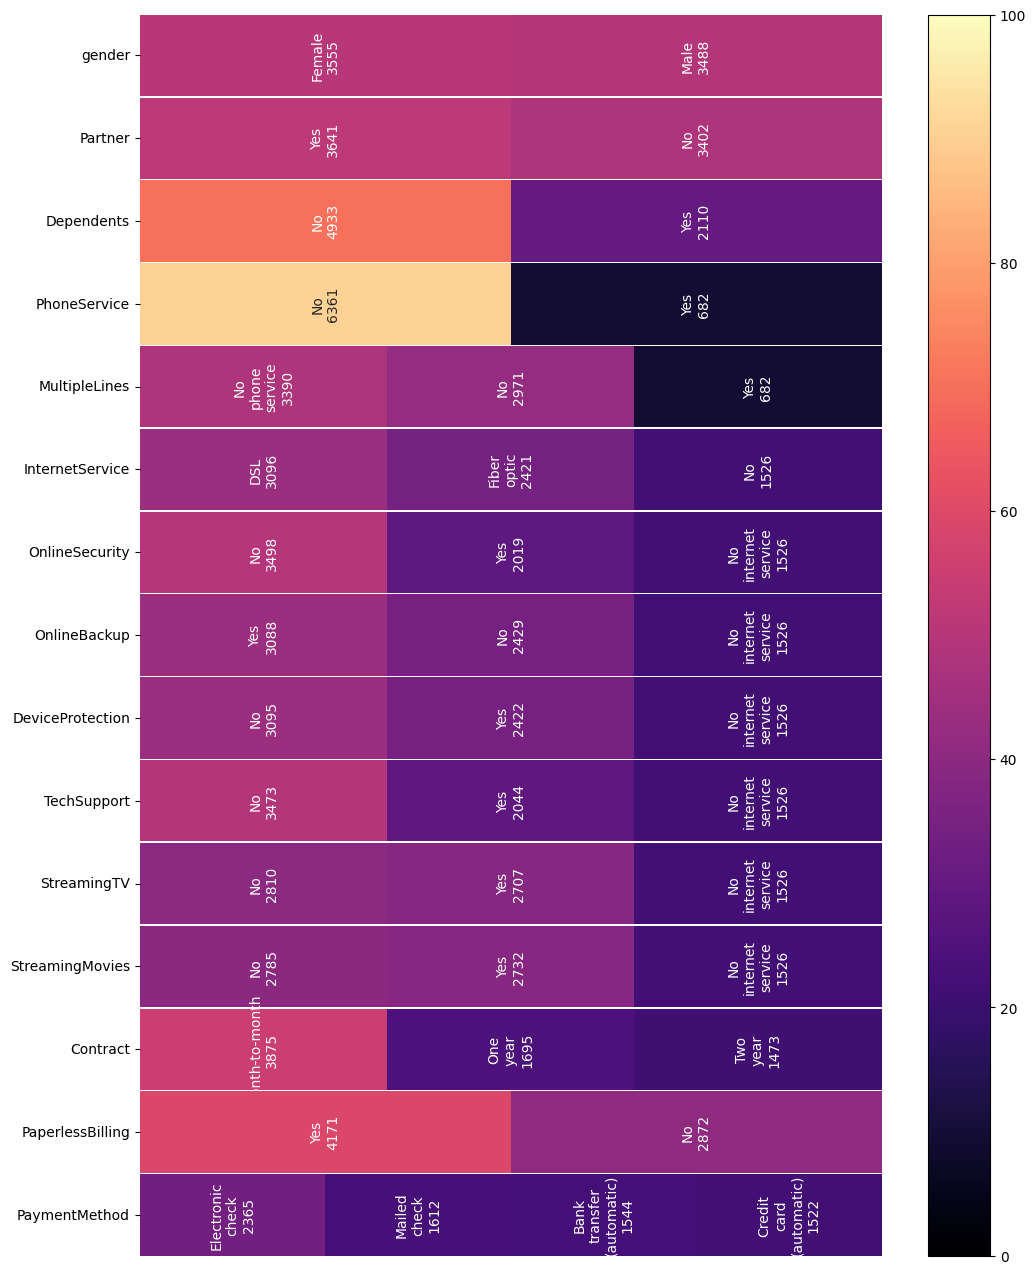

In [64]:
def univariado_categorico(df, maximo = False, figsize = None, cmap="magma", rotacion = 90, numero = False):
    columnas = df.drop(columns='Churn').select_dtypes("object").columns
    figsize = (10, 1+.8*len(columnas)) if figsize is None else figsize
    fig, axes = plt.subplots(len(columnas), 1, figsize = figsize)
    plt.tight_layout(h_pad=-2)

    for ax, col in zip(axes, columnas):
        valores = df[col].value_counts()
        nombres = df[col].unique()
        if numero == "total":
            nombres = nombres +"\n"+valores.astype(str)
        elif numero == "porcentaje":
            nombres = nombres +"\n"+np.round(100*valores/valores.sum(), 1).astype("str") +"%"
        sns.heatmap([valores], annot = [[nom.replace(" ", "\n") for nom in nombres]], fmt = '', ax = ax, cbar = False,
                    cmap = cmap, annot_kws={'rotation': rotacion}, vmin=0,
                    vmax = None if maximo else df[col].value_counts().sum())
        ax.set_xticks([])
        ax.set_yticklabels([col], rotation = 0)

    if not maximo: fig.colorbar(ScalarMappable(Normalize(0, 100), cmap = cmap), ax = axes)

univariado_categorico(df, numero = "total")

#**Análisis de la variable objetivo**

##**Gráfico de Barra de la variable Objetivo**
* Esto sirve para saber si la variable objetivo está desbalanceada.
* Se ve que hay un claro desbalance de clases

/tmp/ipykernel_2390/4043632533.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No', 'Si'], fontweight = 'bold')


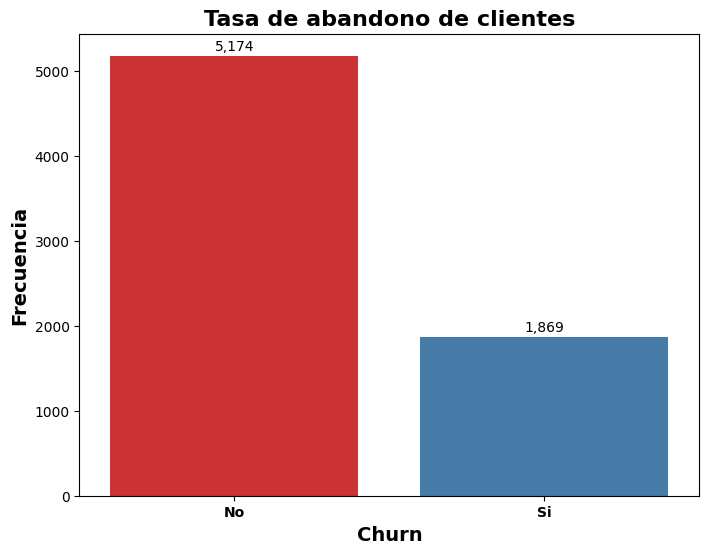

In [65]:
fig, ax = plt.subplots(figsize = (8,6))

ax = sns.countplot(data=df, x='Churn', palette='Set1', hue='Churn')
ax.set_xlabel('Churn', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Frecuencia', fontsize = 14, fontweight = 'bold')
ax.set_title('Tasa de abandono de clientes', fontsize = 16, fontweight = 'bold')
for container in ax.containers:
  ax.bar_label(container, fmt='{:,.0f}',padding=2)
ax.set_xticklabels(['No', 'Si'], fontweight = 'bold')
plt.show()

#**Análisis Bivariado**

##**Análisis Bivariado de variables cuantitativas**
* Es importante este análisis, ya que para modelos lineales como la regresión logística, uno de los supuestos es que no debe haber correlación entre las variables o modelos de base estadística como Naive Bayes que asumen independencia entre ellas.
* En este caso usaré la correlación de spearman, debido a que una variable "tenure" es discreta, mientras que TotalCharges y MontlyCharges son variables continuas.
* Existe una alta correlación entre Tenure y TotalCharges, también entre TotalCharges y MonthlyCharges, lo cual tiene sentido ya que el tiempo que lleve un cliente puede aumentar TotalCharges.


###**Correlación usando coeficiente de Spearman**

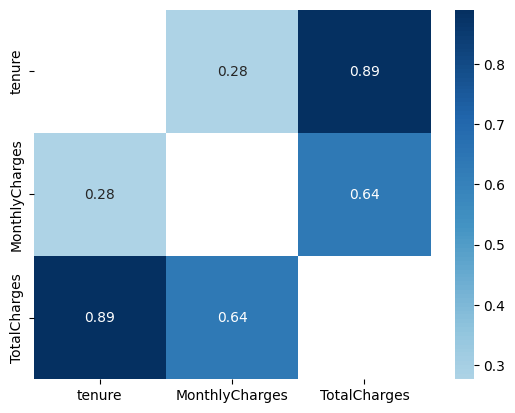

In [66]:

corr = df[df_cuantitativas].corr(method='spearman')
corr[corr == 1] = np.nan
ax = sns.heatmap(corr, annot = True, fmt=".2f", cmap='RdBu', center=0)
plt.show()

##**Análisis Bivariado de las variables cuantitativas vs la variable objetivo**
* Aquí vamos a comprarar la distribución de densidad de las variables cuantitativas con respecto a la variable objetivo, con esto podremos saber si entregan información útil o no.
* La única variable que al parecer no entrega tanta información útil pareciera ser la de Total Charges, ya que cuando el TotalCharges es bajo o cercano a 0, o sea probablemente clientes nuevos, no hay tanta diferencia en la densidad.

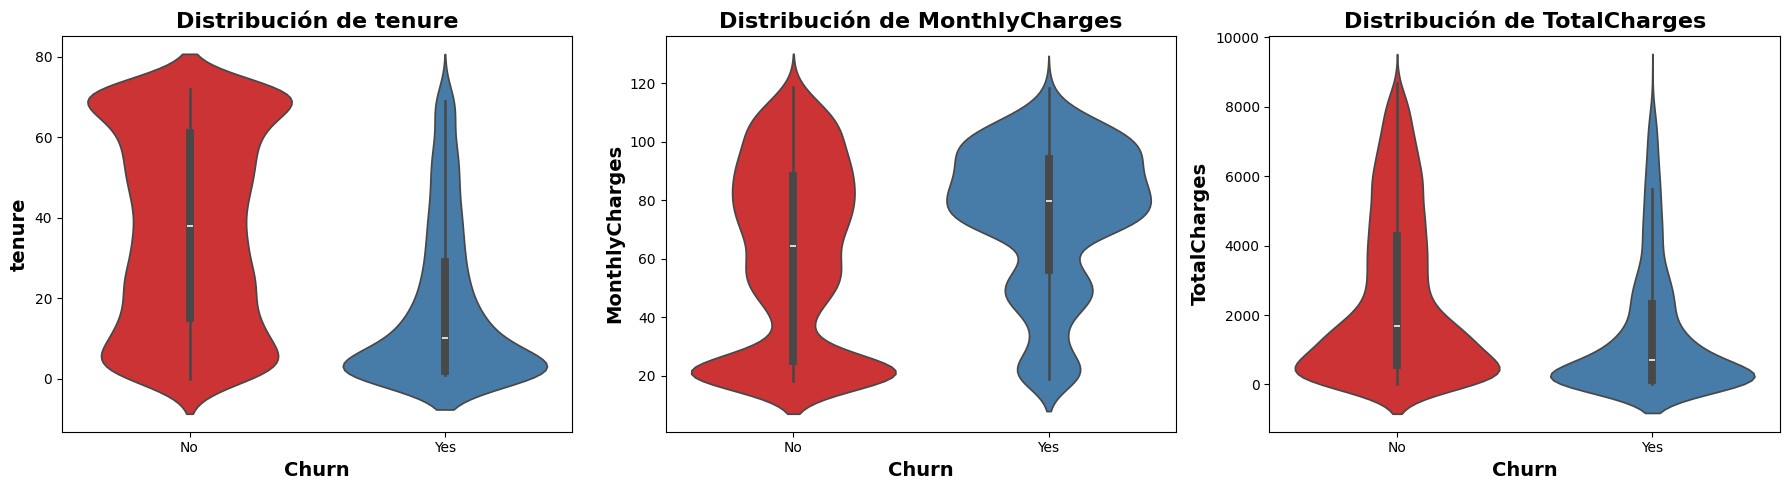

In [67]:

fig, ax = plt.subplots(1, 3, figsize = (18,5))

for j, col in enumerate(df_cuantitativas):
  ax[j] = sns.violinplot(data = df, x='Churn', y=col, ax=ax[j], hue='Churn', palette='Set1')
  ax[j].set_title(f'Distribución de {col}', fontsize = 16, fontweight = 'bold')
  ax[j].set_xlabel(f'Churn', fontsize = 14, fontweight = 'bold')
  ax[j].set_ylabel(f'{col}', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

##**Análisis Bivariado de variables cualitativas y también respecto de la variable objetivo**
* Aquí mediremos qué tan correlacionadas están las variables categóricas entre sí usando la métrica Cramer's V, los valores van de 0 a 1, si es 0 las variables son completamente independientes entre sí, 1 si una variable predice perfectamente a la otra.
* Este tipo de gráficos nos permite identificar que variables están relacionadas con la variable objetivo.
* La variable que está menos correlacionada con la objetivo es el género, servio de teléfono (PhoneService) y multiples líneas (MultipleLines).
* Mientras que las variables que están muy correlacionadas entre si son todas las que dependen de internet para funcionar o están relacionadas a este, por ejemplo InternetService con OnlineSecurity, OnlyneBackup, StreamingMovies, StreamingTv, etc.

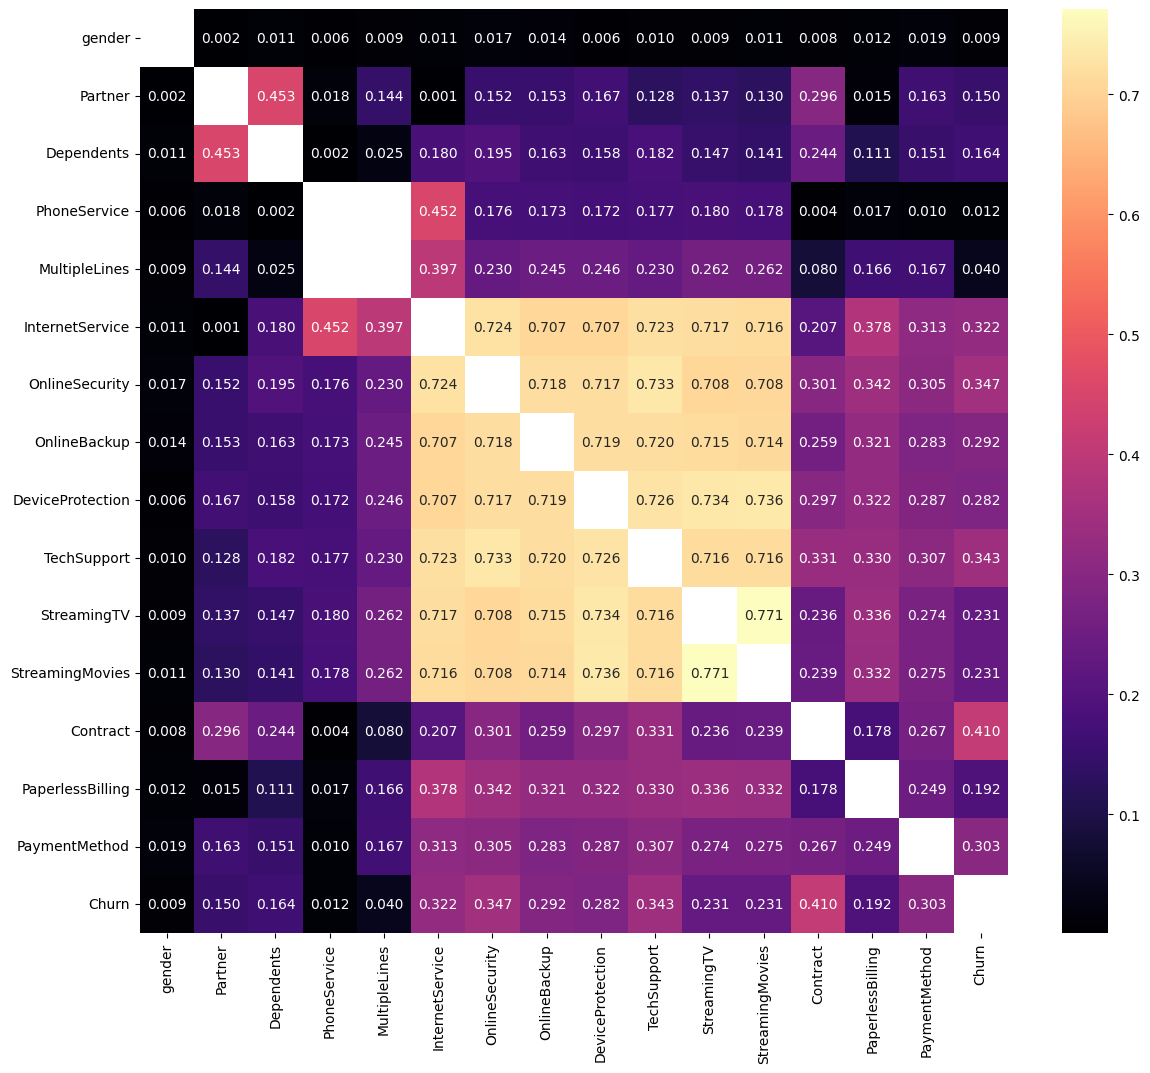

In [68]:
def bivariado_categorico(df, cmap="magma"):
    columnas = df.select_dtypes("object").columns

    df_cramer_v = pd.DataFrame(np.zeros((len(columnas), len(columnas))))
    df_cramer_v.columns, df_cramer_v.index = columnas, columnas

    for col1 in columnas:
        for col2 in columnas:
            df_cramer_v.loc[col1, col2] = association(pd.crosstab(index = df[col1], columns = df[col2]))

    df_cramer_v[df_cramer_v > 0.999] = np.nan

    sns.heatmap(df_cramer_v, annot = True, fmt = ".3f", cmap=cmap)

plt.figure(figsize = (14,12))
bivariado_categorico(df)

#**Conclusiones finales del análisis exploratorio**
* La variable Objetivo se encuentra desbalanceada, por lo que es necesario hacer un balance de datos y utilizar una métrica adecuada como F1 Score, gráfico de Precisión-Sensibilidad, también se deberían probar trheshold distintos a 50%.
* La variable TotalCharges no se utilizará en la elaboración del modelo porque tiene una alta correlación con otras variables, lo cual no es adecuado en los modelos lineales por sus supuestos y además, no la utilizaré en modelos no lineales, porque al hacer el gráfico de densidad se puede ver que no hay una diferencia clara entre el Monto para personas que se quedan con las que se van.
* En cuanto a las variables categóricas, hay una alta correlación entre las variables relacionadas a servicios de internet, por lo que se probarán distintas combinaciones y se usará RFE para revisar cuáles obtiene un mejor modelo.
* Por el momento se descartó el uso de algoritmos como PCA o TNSE debido al bajo número de variables cuantitativas, tal vez más adelante se utilice.

#**Pipeline de Procesamiento de Datos**

##**Transformador personalizado para seleccionar variables**
* Construiré un transformar personalizado que permita seleccionar las variables, ya que se probarán distintas combinaciones de variables y no tener que estar usando drop cada vez.

In [69]:
class ColumnSelector(BaseEstimator, TransformerMixin):
  def __init__(self, columns_to_select):
    self.columns_to_select = columns_to_select

  def fit(self, X, y=None):
    return self

  def transform(self,X):
    return X[self.columns_to_select]

##**Transformar la variable objetivo a 0 y 1**

In [70]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

##**Separar la data en un conjunto de entrenamiento y Test**

In [71]:
X = df.drop(columns = 'Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##**Lista de columnas que se usarán en el pipeline**
* La idea de tener una lista de variables a seleccionar es para evitar tener que estar modificando X a cada momento, ya que se utilizarán distintas combinaciones.
* También se debe tener una lista de variables para las cuales se aplicarán los transformadores como StandardScaler que solo se aplica a variables numéricas, mientras que el OneHotEncoder y LabelEncoder solo lo aplicaremos a las variables de tipo String u Object.

In [72]:
lista_seleccionadas = list(X.drop(columns=['TotalCharges']).columns)
lista_continuas = list(X.select_dtypes('number').drop(columns=['SeniorCitizen','TotalCharges']).columns)
lista_strings = list(X.select_dtypes('object').columns)


##**Pipeline Para Modelos lineales**

###**Pipeline para regresión logística**

In [73]:
pipeline_lr = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('model', LogisticRegressionCV())])

##**Pipeline para modelos no lineales**
* En este caso no es necesario utilizar un escalamiento de las variables ya que los modelos de árboles no son sensibles a la magnitud de las variables continuas, además probaré utilizando LabelEncoder y OneHotEncoder para ver cual da mejores resultados

In [74]:
preprocesor_no_lineal_ohe = ColumnTransformer(transformers = [
    ('encoding', OneHotEncoder(top_categories = None), lista_strings)
])

preprocesor_no_lineal_oe = ColumnTransformer(transformers = [
    'encoding', OrdinalEncoder(encoding_method='ordered'), lista_strings
])

pipeline_no_lineal_ohe = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('preprocesor', preprocesor_no_lineal_ohe)
])


pipeline_no_lineal_oe = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('preprocesor', preprocesor_no_lineal_oe)
])

#**Regresión logística sin balanceo**
* Aquí probaré un primero modelo de regresión logística para tener un primer acercamiento al problema, en el cual no realizaré balanceo, ni ajustaré el threshold para luego ir probando

In [75]:
lr_reference_model = pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

##**Métricas para evaluar el modelo**

##**Classification Report**

In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



##**Curva de precisión sensibilidad**

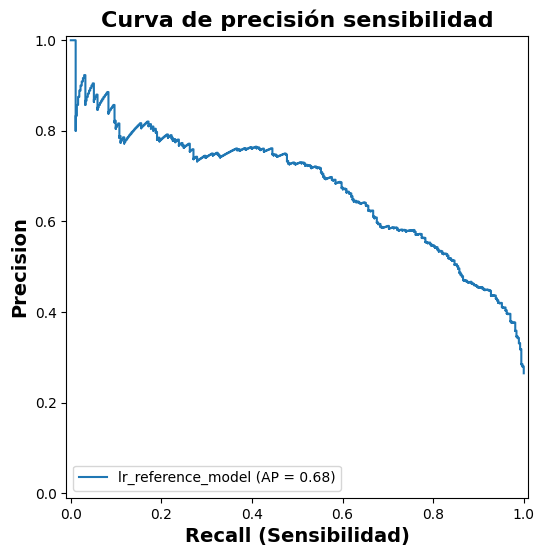

In [77]:
fig, ax = plt.subplots(figsize = (10,6))


PrecisionRecallDisplay.from_estimator(lr_reference_model, X_test, y_test, ax = ax, name='lr_reference_model')
ax.set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
ax.set_title('Curva de precisión sensibilidad', fontsize = 16, fontweight = 'bold')
plt.show()

#**Evaluar el overfitting del modelo**
* Para esto compararemos los resultados que nos dio al predecir el conjunto de test con respecto a los resultados que obtendremos del conjunto de train

In [121]:
y_pred_train = lr_reference_model.predict(X_train)

resultados_train_lr = classification_report(y_train, y_pred_train)
resultados_test_lr = classification_report(y_test, y_pred)

print(f'Resultados conjunto de entrenamiento:  \n\n {resultados_train_lr} \n\n resultados conjunto de test: \n\n {resultados_test_lr}')

Resultados conjunto de entrenamiento:  

               precision    recall  f1-score   support

           0       0.84      0.90      0.87      4138
           1       0.65      0.53      0.59      1496

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.79      0.80      0.79      5634
 

 resultados conjunto de test: 

               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



#**Segundo Modelo Regresión logística con Class_weight**
* Probaré un segundo modelo utilizando el parámetro weighted de regresión logística para que le dé más peso a la clase que aparece menos, para esto debo copiar el Pipeline hecho anteriormente y modificar un parámetro del modelo, se hizo una copia de este en vez de modificar el primer Pipeline para luego poder comparar con otros métodos de balanceo de clases como Smote o NearMiss

In [78]:
lr_balanceado = clone(pipeline_lr)
lr_balanceado.set_params(model = LogisticRegressionCV(class_weight='balanced'))
lr_balanceado.fit(X_train, y_train)
y_pred_lr_balanceado = lr_balanceado.predict(X_test)
y_pred_proba_lr_balanceado = lr_balanceado.predict_proba(X_test)


#**Métricas para evaluar el modelo**

In [79]:
print(classification_report(y_test, y_pred_lr_balanceado))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



#**Crear una función que permita comparar los gráficos de Precisión Sensibilidad de 2 modelos**
* Haré una función para evitar tener que escribir el mismo código una y otra vez.

In [108]:
def graficar_curvas_precision_recall(lista_modelos:list[tuple[BaseEstimator, str]]):
  fig, ax = plt.subplots(1, 2, figsize = (15, 7))

  for j, (model, name) in enumerate(lista_modelos):
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax[j], name=name)
    ax[j].set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
    ax[j].set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
    ax[j].set_title(f'Curva Precisión-Sensibilidad{name}', fontsize = 16, fontweight = 'bold')
  plt.tight_layout()
  plt.show()

#**Comparación de gráficos de Precisión Sensibilidad**

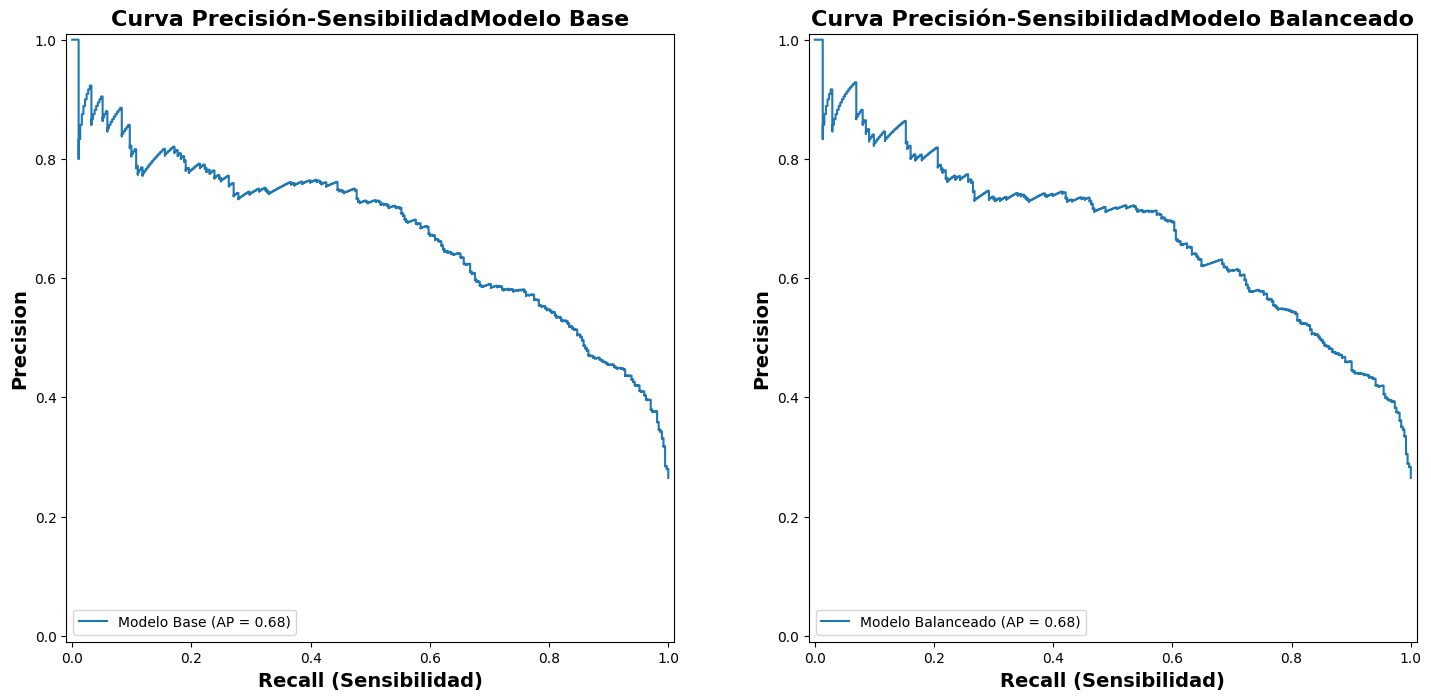

In [111]:
lista_modelos_lr_balanceado = [(lr_reference_model,'Modelo Base'), (lr_balanceado,'Modelo Balanceado')]

graficar_curvas_precision_recall(lista_modelos_lr_balanceado)


#**Modelo utilizando Smote para balancear**
* Aquí crearé un nuevo Pipeline basándome en el original, pero antes de seleccionar el modelo, se agrega una técnica de balanceo llamada SMOTE

In [81]:
lr_smote = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegressionCV())])

lr_smote.fit(X_train, y_train)
y_pred_lr_smote = lr_smote.predict(X_test)
y_pred_proba_lr_smote = lr_smote.predict_proba(X_test)

#**Métricas del modelo Logistic Regression con SMOTE**

In [82]:
print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1036
           1       0.54      0.72      0.62       373

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



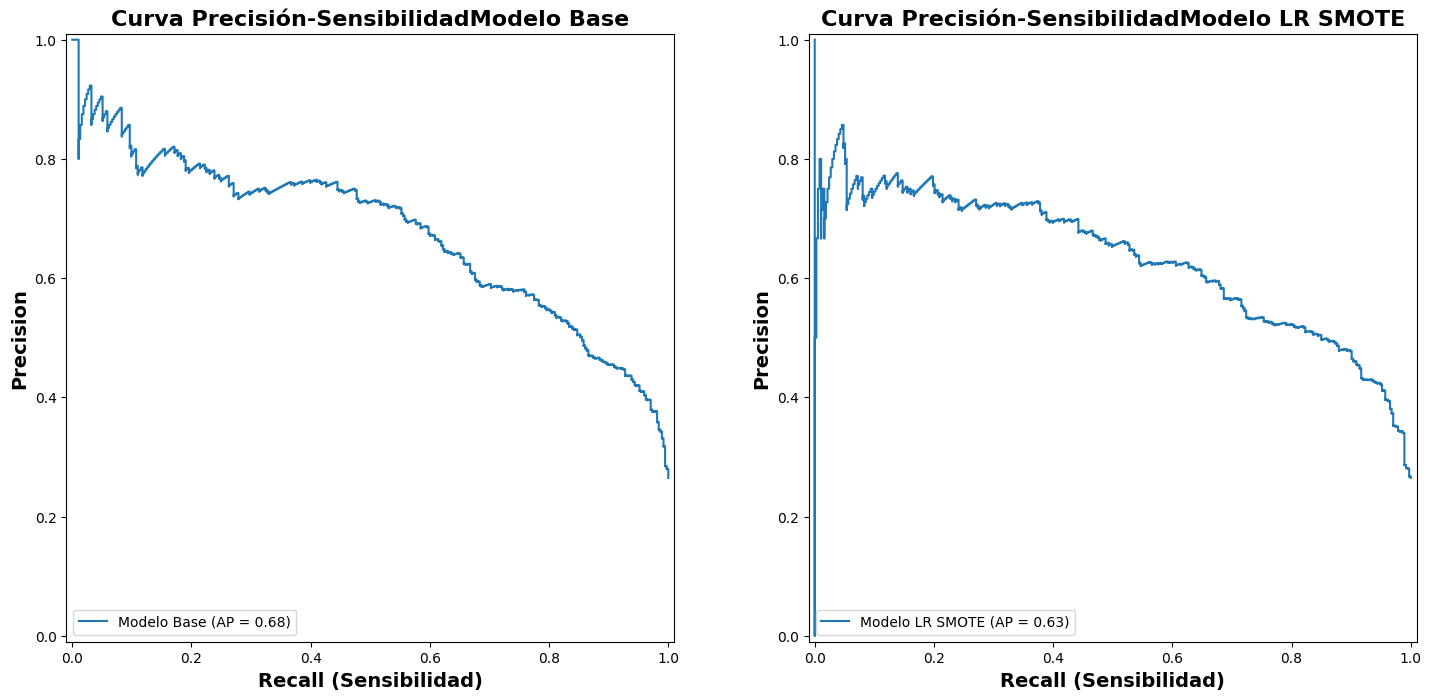

In [113]:
lista_modelos_lr_smote = [(lr_reference_model, 'Modelo Base'), (lr_smote, 'Modelo LR SMOTE')]

graficar_curvas_precision_recall(lista_modelos_lr_smote)


#**Modelo utilizando NearMiss para balancear**
* Ahora se utilizará otra técnica para balancear los datos, también se debe realizar otro Pipeline para procesar estos datos e incluir el balanceador.

In [114]:
lr_near_miss = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('near_miss', NearMiss(version=3)),
    ('model', LogisticRegressionCV())])

lr_near_miss.fit(X_train, y_train)
y_pred_lr_near_miss = lr_near_miss.predict(X_test)
y_pred_proba_lr_near_miss = lr_near_miss.predict_proba(X_test)

#**Métricas para NearMiss**

In [115]:
print(classification_report(y_test, y_pred_lr_near_miss))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1036
           1       0.59      0.72      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



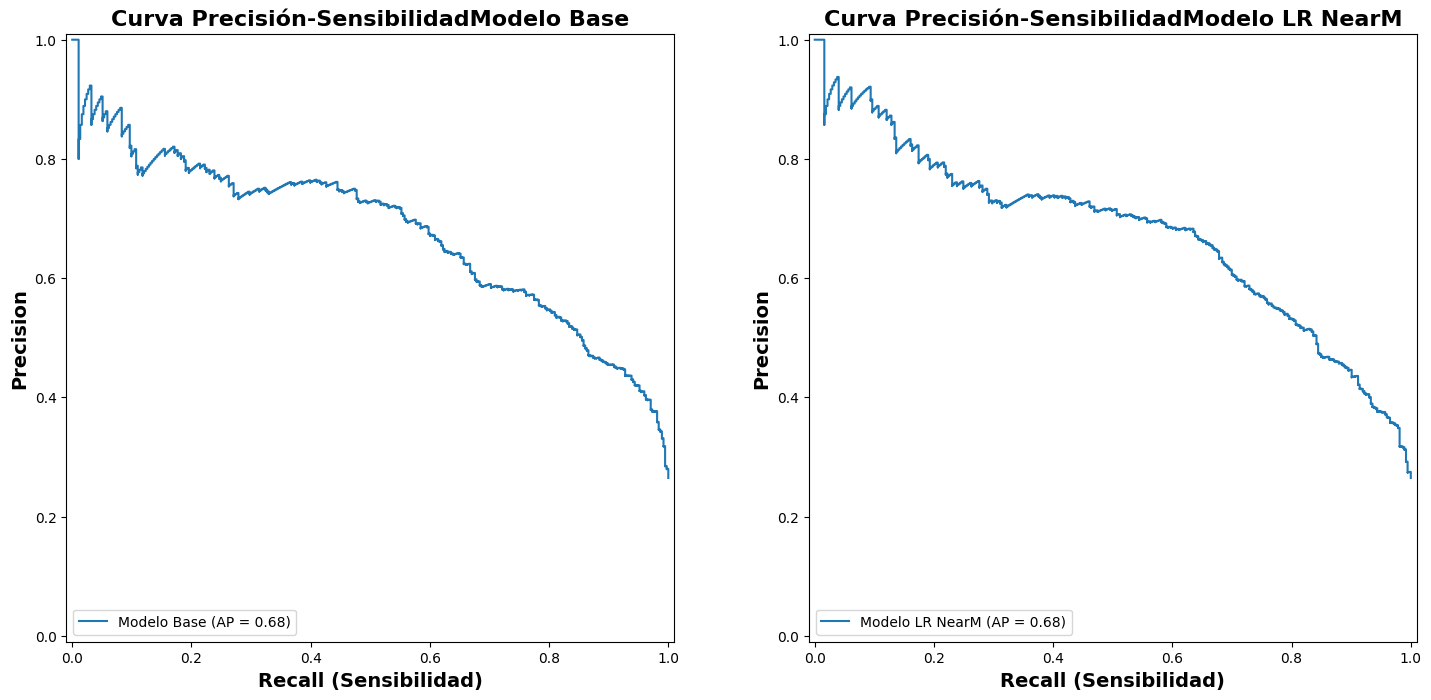

In [117]:
lista_modelos_lr_near_miss = [
    (lr_reference_model,'Modelo Base'), (lr_near_miss,'Modelo LR NearM')]

graficar_curvas_precision_recall(lista_modelos_lr_near_miss)
